# SrTiO3 Berry-curvature validation update

**Meeting:** 31 August 2026  
**System:** SrTiO_3, Ti displaced by $+0.2$ Å along $z$

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

In [2]:
ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / 'data/SrTiO3/Ti_Q_2A').exists()
)
DATA = ROOT / 'data/SrTiO3/Ti_Q_2A'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from modules.berry_curvature import ConnectionAndCurlOmega, compute_omega

In [3]:
def read_json(path):
    with path.open() as handle:
        return json.load(handle)

curve_paths = {
    r'$8^3$': DATA / 'curvature_trial_comparison/generic_line_trace_curvature.csv',
    r'$12^3$': DATA / 'curvature_trial_comparison_nk12_full_A_support/generic_line_trace_curvature.csv',
}
summary_paths = {
    r'$8^3$': DATA / 'curvature_trial_comparison/generic_line_trace_curvature_summary.json',
    r'$12^3$': DATA / 'curvature_trial_comparison_nk12_full_A_support/generic_line_trace_curvature_summary.json',
}
post_summary_paths = {
    r'$8^3$': DATA / 'postw90_reference_comparison/postw90_reference_summary.json',
    r'$12^3$': DATA / 'postw90_reference_comparison_nk12/postw90_reference_summary.json',
}
full_mesh_summary_paths = {
    r'$8^3$': DATA / 'postw90_full_mesh_comparison/full_mesh_summary.json',
    r'$12^3$': DATA / 'postw90_full_mesh_comparison_nk12/full_mesh_summary.json',
}

In [4]:
curves = {label: pd.read_csv(path) for label, path in curve_paths.items()}
summaries = {label: read_json(path) for label, path in summary_paths.items()}
post_summaries = {label: read_json(path) for label, path in post_summary_paths.items()}
full_mesh_summaries = {label: read_json(path) for label, path in full_mesh_summary_paths.items()}

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'font.size': 10,
})
COLORS = {'trial03': '#31688e', 'trial04': '#d1495b', 'postw90': '#2a9d8f', 'in-house MMN': '#7b2cbf'}
print(f'Data loaded from: {DATA}')

Data loaded from: /Users/treycole/Repos/axion-phonon/calculations/SrTiO3/Ti_Q_2A


## 1. Comparison with postw90

The plotted quantity throughout is the occupied-trace Berry curvature
$\boldsymbol\Omega_{\rm tr}$, not a direct relative difference of $A(R)$.

Our `.mmn` construction of $A(R)$ and postw90 use different finite-link phases to construct the same
continuum position connection:

$$
A^{\rm MMN}:\ e^{i\mathbf b\cdot\boldsymbol\tau_j},
\qquad
A^{\rm post}:\ e^{i\mathbf b\cdot(\boldsymbol\tau_i+\boldsymbol\tau_j)/2}
e^{-i\mathbf b\cdot\mathbf R_{ij}/2}.
$$

Both routes evaluate the same three scalars,

$$
\boldsymbol\Omega_{\rm tr}=
(\mathrm{Tr}_{\rm occ}\Omega_{yz},\
 \mathrm{Tr}_{\rm occ}\Omega_{zx},\
 \mathrm{Tr}_{\rm occ}\Omega_{xy}),
$$

at the 202 points postw90 itself stored along the generic line
$\mathbf k(t)=(t,0.30,0.15)$, $0\le t\le1$. 

Running `postw90.x` with 
```text
transl_inv_full=true
use_ws_distance=true,
write_aa_r=true 
```
emits both its own curvature (`SrTiO3-curv.dat`) and its own
position matrix (`SrTiO3_r_full.dat`). We use *that same* $A(R)$ in our code. postw90
documents its printed columns as the negative curvature, so they are
sign-flipped on read.

| | postw90 arm | repository arm |
|---|---|---|
| $A(R)$ | `SrTiO3_r_full.dat` | the same file, installed unmapped |
| $A(k)$, curl | postw90 internal | `WannierConnection`, complex128 |
| $H$ | rebuilt from `.chk` + `.eig` | six-decimal `_hr.dat` |
| $\partial H/\partial k$ | postw90 internal | `model.velocity()` |
| $\Omega$ assembly | postw90 `berry.F90` | `compute_omega`, internal + cross + external |
| occupancy | $E_F=11.0$ eV | `N_OCC = 38` |

postw90 already Wigner–Seitz maps $A(R)$ on export, so it is installed without
a second mapping. Two diagnostics confirm that landed correctly: pair
Hermiticity $\le5.4\times10^{-11}$, and $\sum_R A_{ii}(R)$ reproduces the
`_centres.xyz` Wannier centres to $\sim10^{-8}$ Å.

**$A(R)$ is bit-identical between the arms; $H$ is not.** It is the same
physical Hamiltonian reached by two routes — postw90 rebuilds it internally,
while we read `_hr.dat`, written `F12.6`, so every hopping is quantized at
$10^{-6}$ eV before we see it. That rounding propagates through `velocity()`
into $d_{\mu,cn}=\langle c|\partial_\mu H|n\rangle/(E_n-E_c)$, and therefore
into the internal term only.

Test 1 is therefore *same $A(R)$, same physics, different evaluator, different
$H$ precision*. The residuals separate exactly along that line.

In [5]:
def max_percent(reference, candidate):
    return 100*np.max(np.abs(candidate - reference))/np.max(np.abs(reference))

MESH_LABELS = {r'$8^3$': '8³', r'$12^3$': '12³'}
TEST1_DIRECTORIES = {
    r'$8^3$': 'postw90_reference_comparison',
    r'$12^3$': 'postw90_reference_comparison_nk12',
}
TRIAL_LABELS = {
    'trial03': 'trial 03 — 48 WF, internal term active',
    'trial04': 'trial 04 — 38 WF, no internal term',
}

evaluator, n_points = {}, None
for mesh, directory in TEST1_DIRECTORIES.items():
    frame = pd.read_csv(DATA / directory / 'postw90_reference_curves.csv')
    n_points = len(frame)
    for trial in TRIAL_LABELS:
        reference = np.column_stack(
            [frame[f'{trial}_postw90_{c}_A2'] for c in ('yz', 'zx', 'xy')]
        )
        candidate = np.column_stack(
            [frame[f'{trial}_repository_{c}_A2'] for c in ('yz', 'zx', 'xy')]
        )
        evaluator[(trial, mesh)] = {
            'percent': max_percent(reference, candidate),
            'absolute': float(np.max(np.abs(candidate - reference))),
            'peak': float(np.max(np.abs(reference))),
        }

meshes = list(TEST1_DIRECTORIES)
coarse, dense = meshes
test1 = pd.DataFrame(
    [
        [evaluator[(trial, m)]['percent'] for m in meshes]
        + [evaluator[(trial, m)]['absolute'] for m in meshes]
        + [evaluator[(trial, dense)]['percent'] / evaluator[(trial, coarse)]['percent']]
        for trial in TRIAL_LABELS
    ],
    index=pd.Index(list(TRIAL_LABELS.values())),
    columns=pd.MultiIndex.from_tuples(
        [('maximum difference (%)', MESH_LABELS[m]) for m in meshes]
        + [('largest |Δ| (Å²)', MESH_LABELS[m]) for m in meshes]
        + [('mesh scaling', '12³ / 8³')]
    ),
)

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('caption-side', 'top'), ('text-align', 'left'),
               ('font-size', '100%'), ('padding-bottom', '0.7em'),
               ('line-height', '1.45')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '4px 10px')]},
    {'selector': 'th.row_heading',
     'props': [('text-align', 'left'), ('font-weight', 'normal')]},
    {'selector': 'td', 'props': [('text-align', 'right'), ('padding', '4px 10px')]},
]

display(
    test1.style
    .format('{:.3g}', subset='maximum difference (%)')
    .format('{:.2e}', subset='largest |Δ| (Å²)')
    .format('{:.2f}×', subset='mesh scaling')
    .set_table_styles(TABLE_STYLES)
    .set_caption(
        f'<b>Test 1 — evaluator check on postw90’s stored line</b> '
        f'({n_points} points, k = (t, 0.30, 0.15)).<br>'
        'Both arms use postw90’s exported A(R). H is the same physical '
        'operator at different precision: postw90 rebuilds it internally, the '
        'repository reads six-decimal _hr.dat.<br>'
        'Percentages are max |Δ| over the line divided by the postw90 peak.'
    )
)

With the same postw90 $A(R)$, the repository and postw90 agree to $3.5\times10^{-5}\%$ for trial 04 on both meshes. Trial 03 reaches $0.0303\%$
  at $12^3$, consistent with six-decimal `_hr.dat` entering the internal term.


## 2. $+0.2$ Å trial-set comparison

The line plots show the occupied-trace curvature

$$
\boldsymbol{\Omega}_{\mathrm{tr}}=
(\mathrm{Tr}_{\mathrm{occ}}\Omega_{yz},
 \mathrm{Tr}_{\mathrm{occ}}\Omega_{zx},
 \mathrm{Tr}_{\mathrm{occ}}\Omega_{xy})
$$

along $\mathbf k(t)=(t,0.30,0.15)$. Reported percentages use the complete source mesh:

$$
\Delta_{\max}(\%)=
100\frac{\max_{\mathbf k,c}|\Omega^{(04)}_c-\Omega^{(03)}_c|}
{\max_{\mathbf k,c}|\Omega^{(03)}_c|}.
$$

This peak-normalized maximum avoids singular pointwise percentages at curvature zero-crossings.


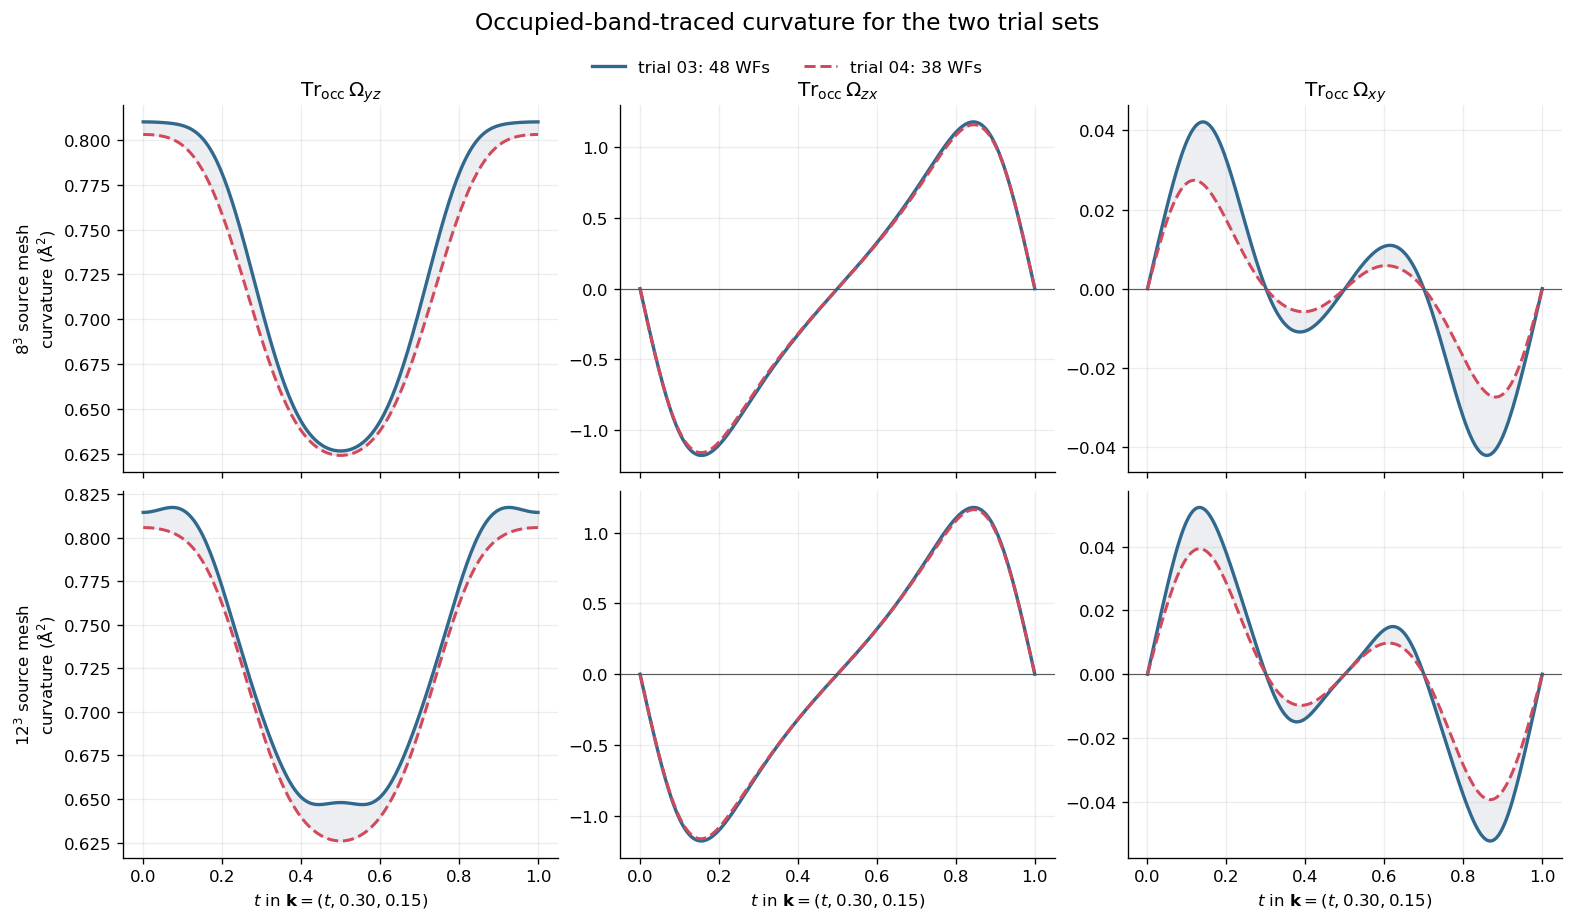

In [8]:
components = [('yz', r'$\mathrm{Tr}_{\rm occ}\,\Omega_{yz}$'),
              ('zx', r'$\mathrm{Tr}_{\rm occ}\,\Omega_{zx}$'),
              ('xy', r'$\mathrm{Tr}_{\rm occ}\,\Omega_{xy}$')]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, constrained_layout=True)
for row, (mesh, frame) in enumerate(curves.items()):
    for col, (component, title) in enumerate(components):
        ax = axes[row, col]
        c03 = f'trial03_trace_omega_{component}_A2'
        c04 = f'trial04_trace_omega_{component}_A2'
        ax.plot(frame['t'], frame[c03], color=COLORS['trial03'], lw=2.0, label='trial 03: 48 WFs')
        ax.plot(frame['t'], frame[c04], color=COLORS['trial04'], lw=1.8, ls='--', label='trial 04: 38 WFs')
        ax.fill_between(frame['t'], frame[c03], frame[c04], color='#8d99ae', alpha=0.16)
        if min(frame[c03].min(), frame[c04].min()) <= 0 <= max(frame[c03].max(), frame[c04].max()):
            ax.axhline(0, color='0.35', lw=0.7)
        ax.set_title(title if row == 0 else '')
        if col == 0:
            ax.set_ylabel(f'{mesh} source mesh\ncurvature (Å$^2$)')
        if row == 1:
            ax.set_xlabel(r'$t$ in $\mathbf{k}=(t,0.30,0.15)$')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.035))
fig.suptitle('Occupied-band-traced curvature for the two trial sets', y=1.075, fontsize=14)
plt.show()


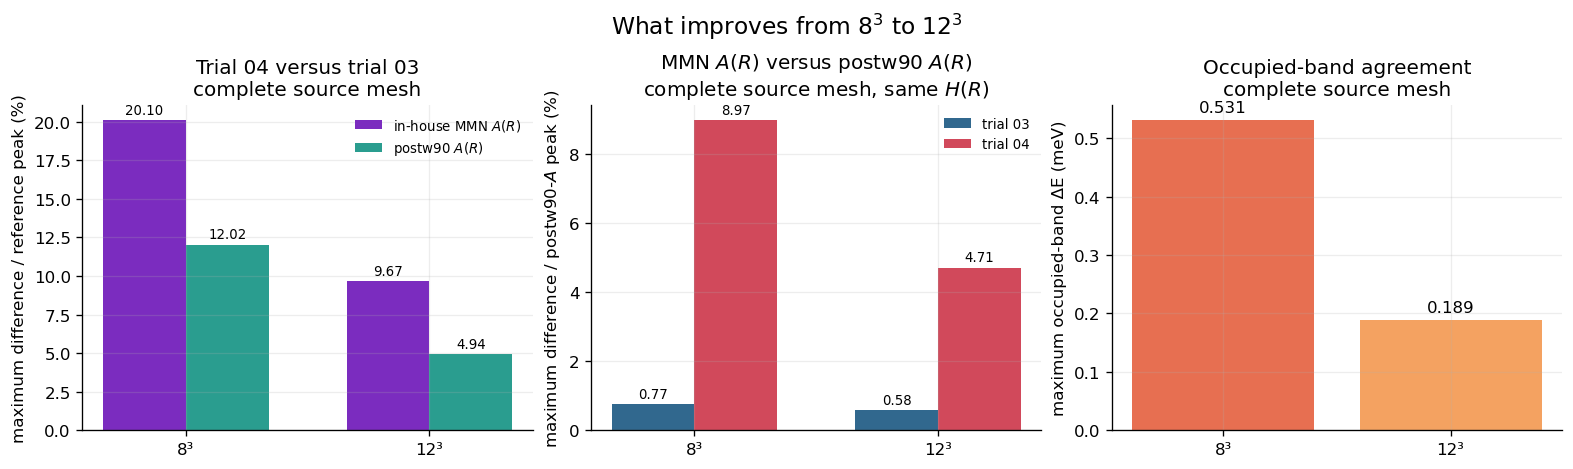

In [9]:
metric_rows = []
for mesh in (r'$8^3$', r'$12^3$'):
    full = full_mesh_summaries[mesh]
    metric_rows.append({
        ('trial 04 versus 03 (%)', 'MMN A'): full['trial_set']['mmn_A']['max_percent_difference'],
        ('trial 04 versus 03 (%)', 'postw90 A'): full['trial_set']['postw90_A']['max_percent_difference'],
        ('MMN versus postw90 A(R) (%)', 'trial 03'): full['position_construction']['trial03']['max_percent_difference'],
        ('MMN versus postw90 A(R) (%)', 'trial 04'): full['position_construction']['trial04']['max_percent_difference'],
        ('occupied bands', 'max ΔE (meV)'): 1e3*summaries[mesh]['max_abs_energy_difference_eV'],
    })
metrics = pd.DataFrame(
    metric_rows,
    index=pd.Index([MESH_LABELS[m] for m in (r'$8^3$', r'$12^3$')]),
)
metrics.columns = pd.MultiIndex.from_tuples(metrics.columns)

display(
    metrics.style
    .format('{:.3f}', subset=list(metrics.columns[:4]))
    .format('{:.4f}', subset=[metrics.columns[4]])
    .set_table_styles(TABLE_STYLES)
    .set_caption(
        '<b>Full-source-mesh maxima.</b> Percentages are the maximum absolute '
        'curvature error divided by the peak reference magnitude, taken over '
        'every source point and all three components.<br>'
        'The occupied-band column is the largest eigenvalue difference between '
        'the two trials and bounds how much of the spread could come from the '
        'electronic structure rather than the interpolation.'
    )
)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
x = np.arange(len(metrics.index)); width = 0.34
for offset, (column, label, color) in zip(
    (-width/2, width/2),
    [(('trial 04 versus 03 (%)', 'MMN A'), 'in-house MMN $A(R)$', COLORS['in-house MMN']),
     (('trial 04 versus 03 (%)', 'postw90 A'), 'postw90 $A(R)$', COLORS['postw90'])],
):
    bars = axes[0].bar(x + offset, metrics[column], width, label=label, color=color)
    axes[0].bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
axes[0].set_xticks(x, list(metrics.index))
axes[0].set_ylabel('maximum difference / reference peak (%)')
axes[0].set_title('Trial 04 versus trial 03\ncomplete source mesh')
axes[0].legend(frameon=False, fontsize=8)

for offset, (column, label, color) in zip(
    (-width/2, width/2),
    [(('MMN versus postw90 A(R) (%)', 'trial 03'), 'trial 03', COLORS['trial03']),
     (('MMN versus postw90 A(R) (%)', 'trial 04'), 'trial 04', COLORS['trial04'])],
):
    bars = axes[1].bar(x + offset, metrics[column], width, label=label, color=color)
    axes[1].bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
axes[1].set_xticks(x, list(metrics.index))
axes[1].set_ylabel('maximum difference / postw90-$A$ peak (%)')
axes[1].set_title('MMN $A(R)$ versus postw90 $A(R)$\ncomplete source mesh, same $H(R)$')
axes[1].legend(frameon=False, fontsize=8)

bars = axes[2].bar(x, metrics[('occupied bands', 'max ΔE (meV)')], color=['#e76f51', '#f4a261'])
axes[2].bar_label(bars, fmt='%.3f', padding=3)
axes[2].set_xticks(x, list(metrics.index))
axes[2].set_ylabel('maximum occupied-band ΔE (meV)')
axes[2].set_title('Occupied-band agreement\ncomplete source mesh')
fig.suptitle(r'What improves from $8^3$ to $12^3$', fontsize=14)
plt.show()

### What $8^3$ versus $12^3$ means

These are first-principles source meshes, not denser evaluation meshes.

| quantity | $8^3$ | $12^3$ |
|---|---:|---:|
| source points | 512 | 1,728 |
| link scale | $\sim1/8$ | $\sim1/12$ |
| pair-mapped $R$ support | 729 | 2,197 |

Although $P_{03}(\mathbf k_l)=P_{04}(\mathbf k_l)$ at sampled points, curvature depends on derivatives:

$$\Omega_{ij}=-i\,\mathrm{Tr}\,P[\partial_iP,\partial_jP].$$

Trial 03 represents virtual transitions through 10 in-model empty states; trial 04 places that information in the external position matrix. A denser source mesh better constrains these derivatives. All measured differences decrease on $12^3$, but two meshes do not prove convergence.


## 3. Analytic model

The model starts with known curvature, then applies a momentum-dependent basis rotation. This makes all three implemented curvature terms nonzero without changing the physical state.

### Exact reference

Let

$$
\phi=2\pi k_y,\qquad
\theta=0.47+0.23\sin(2\pi k_x),\qquad
|u\rangle=\begin{pmatrix}\cos\theta\\e^{i\phi}\sin\theta\end{pmatrix},
$$

and $H=I-2|u\rangle\langle u|$. With $A_\mu=i\langle u|\partial_\mu u\rangle$,

$$
A_x=0,\qquad A_y=-2\pi\sin^2\theta,
$$

$$
\boxed{\Omega^{\rm exact}_{xy}
=\partial_xA_y-\partial_yA_x
=-4\pi\sin\theta\cos\theta\,\theta'.}
$$

This is the independent reference.

### Internal and external connection

Define Hilbert-space rotations

$$
R_x(\alpha)=e^{-i\alpha\sigma_x/2},\qquad
R_y(\beta)=e^{-i\beta\sigma_y/2},
$$

with $\alpha=0.71\sin(2\pi k_x)$, $\beta=0.53\sin(2\pi k_y)$, and

$$G=R_xR_y,\qquad |v\rangle=G^\dagger|u\rangle,\qquad H'=G^\dagger HG.$$

The momentum-dependent basis generates the basis connection

$$
\mathcal A^{\rm basis}_\mu=iG^\dagger\partial_\mu G,
$$

$$
\mathcal A^{\rm basis}_x=\frac{\alpha'}2(\sigma_x\cos\beta+\sigma_z\sin\beta),
\qquad
\mathcal A^{\rm basis}_y=\frac{\beta'}2\sigma_y.
$$

From $|u\rangle=G|v\rangle$,

$$
|\partial_\mu u\rangle=(\partial_\mu G)|v\rangle+G|\partial_\mu v\rangle,
$$

so

$$
\boxed{A_\mu=
\underbrace{i\langle v|\partial_\mu v\rangle}_{A_\mu^{\rm int}}
+
\underbrace{\langle v|\mathcal A^{\rm basis}_\mu|v\rangle}_{A_\mu^{\rm ext}}.}
$$

The external term therefore comes only from the moving basis.

### Curvature computed by the implementation

For occupied state $|n\rangle$ and empty state $|c\rangle$,

$$
d_{\mu,cn}=\frac{\langle c|\partial_\mu H'|n\rangle}{E_n-E_c},
\qquad
a_{\mu,cn}=\langle c|\mathcal A^{\rm basis}_\mu|n\rangle.
$$

With $a_\mu^{oo}=\langle n|\mathcal A^{\rm basis}_\mu|n\rangle$ and
$\bar\omega_{xy}^{oo}=\langle n|\partial_x\mathcal A^{\rm basis}_y-\partial_y\mathcal A^{\rm basis}_x|n\rangle$,

$$
\boxed{\Omega^{\rm int}_{xy}=i(d_x^\dagger d_y-d_y^\dagger d_x),}
$$

$$
\boxed{\Omega^{\rm cross}_{xy}
=(d_x^\dagger a_y+\mathrm{h.c.})-(a_x^\dagger d_y+\mathrm{h.c.}),}
$$

$$
\boxed{\Omega^{\rm ext}_{xy}
=\bar\omega^{oo}_{xy}-i[a_x^{oo},a_y^{oo}].}
$$

Thus

$$
\boxed{\Omega^{\rm total}_{xy}
=\Omega^{\rm int}_{xy}+\Omega^{\rm cross}_{xy}+\Omega^{\rm ext}_{xy}.}
$$

For this pure-gauge basis,
$\partial_x\mathcal A^{\rm basis}_y-\partial_y\mathcal A^{\rm basis}_x=i[\mathcal A^{\rm basis}_x,\mathcal A^{\rm basis}_y]$.
The full-space field strength vanishes, but its occupied projection need not.

The plots check both $A^{\rm int}+A^{\rm ext}=A$ and
$\Omega^{\rm int}+\Omega^{\rm cross}+\Omega^{\rm ext}=\Omega^{\rm exact}$.
The table also compares production output with independent NumPy formulas and tests a nonzero occupied-space commutator in a three-band model.


In [10]:
def analytic_two_level(kpoints):
    kpoints = np.asarray(kpoints, float)
    x, y = 2*np.pi*kpoints[:, 0], 2*np.pi*kpoints[:, 1]
    theta = 0.47 + 0.23*np.sin(x)
    dtheta_dx = 2*np.pi*0.23*np.cos(x)
    dphase_dy = 2*np.pi
    u = np.stack([np.cos(theta), np.exp(1j*y)*np.sin(theta)], axis=1)
    du_x = np.stack([-np.sin(theta)*dtheta_dx, np.exp(1j*y)*np.cos(theta)*dtheta_dx], axis=1)
    du_y = np.stack([np.zeros_like(theta), 1j*dphase_dy*np.exp(1j*y)*np.sin(theta)], axis=1)
    projector = np.einsum('ki,kj->kij', u, u.conj())
    H = np.eye(2)[None] - 2*projector
    dH = np.zeros((3, len(kpoints), 2, 2), complex)
    for axis, du in enumerate((du_x, du_y)):
        dH[axis] = -2*(np.einsum('ki,kj->kij', du, u.conj()) + np.einsum('ki,kj->kij', u, du.conj()))
    expected = -2*dphase_dy*np.sin(theta)*np.cos(theta)*dtheta_dx
    return H, dH, expected, u, (du_x, du_y), theta

def pauli_rotation_and_derivative(generator, angle, derivative):
    identity = np.eye(len(generator), dtype=complex)
    active = generator @ generator
    rotation = identity + (np.cos(angle/2)-1)*active - 1j*np.sin(angle/2)*generator
    drotation = derivative*(-0.5*np.sin(angle/2)*active - 0.5j*np.cos(angle/2)*generator)
    return rotation, drotation

def rotate_frame(kpoints, H, dH, generator_x, generator_y):
    H_rot = np.empty_like(H)
    dH_rot = np.zeros_like(dH)
    A = np.zeros((len(kpoints), 3, H.shape[-1], H.shape[-1]), complex)
    for ik, (kx, ky, *_) in enumerate(kpoints):
        x, y = 2*np.pi*kx, 2*np.pi*ky
        alpha, beta = 0.71*np.sin(x), 0.53*np.sin(y)
        dalpha, dbeta = 0.71*2*np.pi*np.cos(x), 0.53*2*np.pi*np.cos(y)
        Rx, dRx = pauli_rotation_and_derivative(generator_x, alpha, dalpha)
        Ry, dRy = pauli_rotation_and_derivative(generator_y, beta, dbeta)
        G, dGs = Rx @ Ry, (dRx @ Ry, Rx @ dRy)
        H_rot[ik] = G.conj().T @ H[ik] @ G
        for mu, dG in enumerate(dGs):
            dH_rot[mu, ik] = (dG.conj().T @ H[ik] @ G + G.conj().T @ dH[mu, ik] @ G + G.conj().T @ H[ik] @ dG)
            A[ik, mu] = 1j * G.conj().T @ dG
    curl = np.zeros_like(A)
    curl[:, 2] = 1j*(A[:, 0] @ A[:, 1] - A[:, 1] @ A[:, 0])
    return H_rot, dH_rot, A, curl

def split_occupied_connection(kpoints, u, du, generator_x, generator_y):
    internal = np.zeros((len(kpoints), 2), complex)
    external = np.zeros_like(internal)
    for ik, (kx, ky, *_) in enumerate(kpoints):
        x, y = 2*np.pi*kx, 2*np.pi*ky
        alpha, beta = 0.71*np.sin(x), 0.53*np.sin(y)
        dalpha, dbeta = 0.71*2*np.pi*np.cos(x), 0.53*2*np.pi*np.cos(y)
        Rx, dRx = pauli_rotation_and_derivative(generator_x, alpha, dalpha)
        Ry, dRy = pauli_rotation_and_derivative(generator_y, beta, dbeta)
        G, dGs = Rx @ Ry, (dRx @ Ry, Rx @ dRy)
        v = G.conj().T @ u[ik]
        for mu, dG in enumerate(dGs):
            dv = dG.conj().T @ u[ik] + G.conj().T @ du[mu][ik]
            basis_A = 1j * G.conj().T @ dG
            internal[ik, mu] = 1j*np.vdot(v, dv)
            external[ik, mu] = np.vdot(v, basis_A @ v)
    return internal.real, external.real

def decompose_curvature_numpy(H, dH, occupied, A=None, curl=None):
    energies, vectors = np.linalg.eigh(H)
    occupied = np.asarray(occupied, int)
    empty = np.setdiff1d(np.arange(H.shape[-1]), occupied)
    shape = (3, 3, len(H), len(occupied), len(occupied))
    internal, cross, external = (np.zeros(shape, complex) for _ in range(3))
    for ik in range(len(H)):
        U = vectors[ik]
        dH_band = np.array([U.conj().T @ dH[mu, ik] @ U for mu in range(3)])
        gaps = energies[ik, occupied][None, :] - energies[ik, empty][:, None]
        D_eo = dH_band[:, empty[:, None], occupied[None, :]] / gaps
        D_oe = dH_band[:, occupied[:, None], empty[None, :]] / gaps.T
        for mu in range(3):
            for nu in range(3):
                Q = D_oe[mu] @ D_eo[nu]
                internal[mu, nu, ik] = 1j*(Q - Q.conj().T)
        if A is None:
            continue
        A_band = np.array([U.conj().T @ A[ik, mu] @ U for mu in range(3)])
        curl_band = np.array([U.conj().T @ curl[ik, dual] @ U for dual in range(3)])
        for mu, nu, dual in [(1, 2, 0), (2, 0, 1), (0, 1, 2)]:
            Aeo_mu = A_band[mu][empty[:, None], occupied[None, :]]
            Aeo_nu = A_band[nu][empty[:, None], occupied[None, :]]
            term = Aeo_mu.conj().T @ D_eo[nu]
            cross_part = -(term + term.conj().T)
            term = D_eo[mu].conj().T @ Aeo_nu
            cross_part += term + term.conj().T
            Aoo_mu = A_band[mu][occupied[:, None], occupied[None, :]]
            Aoo_nu = A_band[nu][occupied[:, None], occupied[None, :]]
            external_part = curl_band[dual][occupied[:, None], occupied[None, :]] - 1j*(Aoo_mu @ Aoo_nu - Aoo_nu @ Aoo_mu)
            cross[mu, nu, ik], cross[nu, mu, ik] = cross_part, -cross_part
            external[mu, nu, ik], external[nu, mu, ik] = external_part, -external_part
    return internal, cross, external


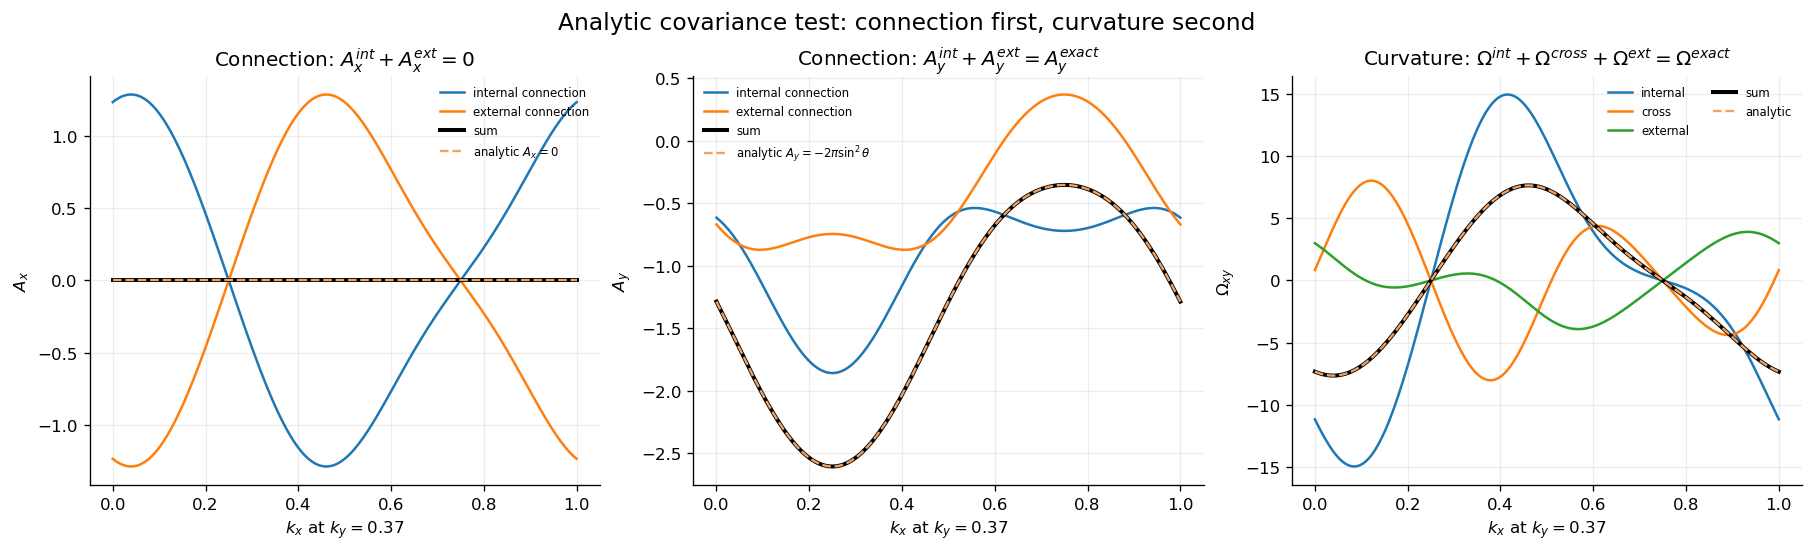

,maximum absolute value,criterion
check,,
connection A: internal + external versus analytic,1.332e-15,< 1e-11
two-band NumPy curvature sum versus analytic,1.688e-14,< 1e-11
two-band production curvature sum versus analytic,1.510e-14,< 1e-11
two-band production pieces versus NumPy formulas,2.487e-14,< 1e-11
three-band production total versus analytic,1.155e-14,< 1e-11
three-band production pieces versus NumPy formulas,2.132e-14,< 1e-11
three-band occupied commutator (must be nonzero),4.109e+00,> 1e-2


In [11]:
kline = np.column_stack([np.linspace(0, 1, 201), np.full(201, 0.37), np.zeros(201)])
H, dH, omega_exact, u, du, theta = analytic_two_level(kline)
sigma_x = np.array([[0, 1], [1, 0]], complex)
sigma_y = np.array([[0, -1j], [1j, 0]], complex)
H_rot, dH_rot, A, curl = rotate_frame(kline, H, dH, sigma_x, sigma_y)

# Connection-level identity: coefficient motion + basis motion = physical connection.
connection_int, connection_ext = split_occupied_connection(kline, u, du, sigma_x, sigma_y)
connection_exact = np.column_stack([np.zeros(len(kline)), -2*np.pi*np.sin(theta)**2])
connection_total = connection_int + connection_ext
connection_error = np.max(np.abs(connection_total - connection_exact))

# Independent NumPy transcription of the production curvature formulas.
omega_int, omega_cross, omega_ext = decompose_curvature_numpy(H_rot, dH_rot, [0], A, curl)
numpy_arrays = {'internal': omega_int, 'cross': omega_cross, 'external': omega_ext}
parts = {name: values[0, 1, :, 0, 0].real for name, values in numpy_arrays.items()}
omega_total = sum(parts.values())
numpy_total_error = np.max(np.abs(omega_total - omega_exact))

# Actual repository implementation, supplied with the same analytic inputs.
production = compute_omega(
    H_rot, dH_rot, [0],
    connection=ConnectionAndCurlOmega(A=A, curl_Omega=curl),
    return_parts=True,
)
production_arrays = {
    'internal': production.internal, 'cross': production.cross, 'external': production.external
}
production_total = production.total[0, 1, :, 0, 0].real
production_total_error = np.max(np.abs(production_total - omega_exact))
production_split_error = max(
    np.max(np.abs(production_arrays[name] - numpy_arrays[name])) for name in numpy_arrays
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for axis, component, exact_label in [(axes[0], 0, r'analytic $A_x=0$'),
                                      (axes[1], 1, r'analytic $A_y=-2\pi\sin^2\theta$')]:
    axis.plot(kline[:, 0], connection_int[:, component], lw=1.5, label='internal connection')
    axis.plot(kline[:, 0], connection_ext[:, component], lw=1.5, label='external connection')
    axis.plot(kline[:, 0], connection_total[:, component], color='black', lw=2.4, label='sum')
    axis.plot(kline[:, 0], connection_exact[:, component], color='#f4a261', lw=1.4, ls='--', label=exact_label)
    axis.set_xlabel(r'$k_x$ at $k_y=0.37$')
    axis.legend(frameon=False, fontsize=7)
axes[0].set(ylabel=r'$A_x$', title=r'Connection: $A_x^{int}+A_x^{ext}=0$')
axes[1].set(ylabel=r'$A_y$', title=r'Connection: $A_y^{int}+A_y^{ext}=A_y^{exact}$')
for label, values in parts.items():
    axes[2].plot(kline[:, 0], values, lw=1.5, label=label)
axes[2].plot(kline[:, 0], omega_total, color='black', lw=2.4, label='sum')
axes[2].plot(kline[:, 0], omega_exact, color='#f4a261', lw=1.4, ls='--', label='analytic')
axes[2].set(xlabel=r'$k_x$ at $k_y=0.37$', ylabel=r'$\Omega_{xy}$',
            title=r'Curvature: $\Omega^{int}+\Omega^{cross}+\Omega^{ext}=\Omega^{exact}$')
axes[2].legend(frameon=False, fontsize=7, ncol=2)
fig.suptitle('Analytic covariance test: connection first, curvature second', fontsize=14)
plt.show()

# Three-band extension: two occupied bands, one empty band.
H3 = np.zeros((len(kline), 3, 3), complex)
H3[:, 0, 0] = -2.0
H3[:, 1:, 1:] = H
dH3 = np.zeros((3, len(kline), 3, 3), complex)
dH3[:, :, 1:, 1:] = dH
gx3, gy3 = np.zeros((3, 3), complex), np.zeros((3, 3), complex)
gx3[:2, :2], gy3[:2, :2] = sigma_x, sigma_y
H3r, dH3r, A3, curl3 = rotate_frame(kline, H3, dH3, gx3, gy3)
i3, c3, e3 = decompose_curvature_numpy(H3r, dH3r, [0, 1], A3, curl3)
expected3 = np.zeros_like(i3)
expected3[0, 1, :, 1, 1] = omega_exact
expected3[1, 0, :, 1, 1] = -omega_exact
production3 = compute_omega(
    H3r, dH3r, [0, 1],
    connection=ConnectionAndCurlOmega(A=A3, curl_Omega=curl3),
    return_parts=True,
)
three_band_total_error = np.max(np.abs(production3.total - expected3))
# NumPy and TensorFlow diagonalizers choose different band phases. Align the
# independent NumPy matrices to the production (TensorFlow) band gauge.
_, vectors3 = np.linalg.eigh(H3r)
_, vectors3_tf = tf.linalg.eigh(tf.constant(H3r, dtype=tf.complex128))
vectors3_tf = vectors3_tf.numpy()
def align_occupied_gauge(field, source_vectors, target_vectors, nocc):
    aligned = np.empty_like(field)
    for ik in range(len(source_vectors)):
        W = source_vectors[ik, :, :nocc].conj().T @ target_vectors[ik, :, :nocc]
        for mu in range(field.shape[0]):
            for nu in range(field.shape[1]):
                aligned[mu, nu, ik] = W.conj().T @ field[mu, nu, ik] @ W
    return aligned
aligned_i3 = align_occupied_gauge(i3, vectors3, vectors3_tf, 2)
aligned_c3 = align_occupied_gauge(c3, vectors3, vectors3_tf, 2)
aligned_e3 = align_occupied_gauge(e3, vectors3, vectors3_tf, 2)
three_band_split_error = max(
    np.max(np.abs(actual - expected))
    for actual, expected in [(production3.internal, aligned_i3),
                             (production3.cross, aligned_c3),
                             (production3.external, aligned_e3)]
)
max_commutator = 0.0
for ik in range(len(kline)):
    Uocc = vectors3[ik, :, :2]
    Aocc = [Uocc.conj().T @ A3[ik, mu] @ Uocc for mu in (0, 1)]
    comm = -1j*(Aocc[0] @ Aocc[1] - Aocc[1] @ Aocc[0])
    max_commutator = max(max_commutator, float(np.max(np.abs(comm))))

part_magnitudes = {name: np.max(np.abs(values)) for name, values in parts.items()}
assert connection_error < 1e-11
assert numpy_total_error < 1e-11 and production_total_error < 1e-11
assert production_split_error < 1e-11 and three_band_split_error < 1e-11
assert three_band_total_error < 1e-11 and max_commutator > 1e-2
assert min(part_magnitudes.values()) > 1e-2

verification = pd.DataFrame([
    ('connection A: internal + external versus analytic', connection_error, '< 1e-11'),
    ('two-band NumPy curvature sum versus analytic', numpy_total_error, '< 1e-11'),
    ('two-band production curvature sum versus analytic', production_total_error, '< 1e-11'),
    ('two-band production pieces versus NumPy formulas', production_split_error, '< 1e-11'),
    ('three-band production total versus analytic', three_band_total_error, '< 1e-11'),
    ('three-band production pieces versus NumPy formulas', three_band_split_error, '< 1e-11'),
    ('three-band occupied commutator (must be nonzero)', max_commutator, '> 1e-2'),
], columns=['check', 'maximum absolute value', 'criterion']).set_index('check')
display(verification.style.format({'maximum absolute value': '{:.3e}'}).set_caption(
    'Analytic-model verification: the production implementation is tested against independent formulas'
))


### Reading the analytic test

- First two panels: internal + external connection reproduces analytic $A_x$ and $A_y$.
- Third panel: internal + cross + external curvature reproduces $\Omega^{\rm exact}$.
- Table: analytic, NumPy, and production results agree below $10^{-11}$; the three-band test checks the non-Abelian commutator.

This validates the algebra and code for exact inputs, not the finite-mesh construction of first-principles $A(R)$.


## Conclusion

- The occupied projectors agree at source points, and the curvature implementation passes analytic and postw90 checks.
- The remaining trial spread is consistent with finite-source-mesh derivative ambiguity.
- Proceed with physical-mode work, quoting trial spread as interpolation uncertainty.

### Next checks

1. Add a third source mesh, preferably $16^3$.
2. Test a smaller displacement before taking displacement derivatives.
3. Validate the physical $\beta$-connection or endpoint parallel transport.


## Sources

- [Full validation](../notes/log/2026-08-27_Ti_Q_2A_full_validation.md)
- [$12^3$ $A(R)$ comparison](../notes/log/2026-08-28_Ti_Q_2A_nk12_A_R_comparison.md)
- [postw90 vs MMN construction](../notes/log/2026-08-27_rfull_vs_mmn_position_matrix.md)

Plot inputs are under calculations/SrTiO3/Ti_Q_2A; the analytic test follows tests/test_berry_curvature_covariance.py.
